# Cafe Sales Analysis

Quick data cleaning and exploration on cafe sales. 10k transactions to sort through, then export clean data for Tableau.

**What's here:**
1. Data Loading
2. Data Cleaning
3. Descriptive Stats
4. Univariate Analysis
5. Bivariate Analysis
6. Time-based Trends
7. Takeaways
8. Export for Tableau

## 1. Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('dirty_cafe_sales.csv')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Shape: 10000 rows, 8 columns


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [6]:
df.describe(include='all')


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


## 2. Clean Data

The data has `ERROR`, `UNKNOWN`, blanks, and `NaN` scattered around that all need to be treated as missing.

In [7]:
placeholder_vals = ['ERROR', 'UNKNOWN', '', 'nan', 'NaN']
df_clean = df.copy()
for col in df_clean.columns:
    df_clean[col] = df_clean[col].replace(placeholder_vals, np.nan)

# Convert types
df_clean['Quantity'] = pd.to_numeric(df_clean['Quantity'], errors='coerce')
df_clean['Price Per Unit'] = pd.to_numeric(df_clean['Price Per Unit'], errors='coerce')
df_clean['Total Spent'] = pd.to_numeric(df_clean['Total Spent'], errors='coerce')
df_clean['Transaction Date'] = pd.to_datetime(df_clean['Transaction Date'], errors='coerce')

print("Missing before imputation:")
print(df_clean.isna().sum())

Missing before imputation:
Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


In [8]:
# Build item -> price lookup
price_map = (
    df_clean.dropna(subset=['Item', 'Price Per Unit'])
    .groupby('Item')['Price Per Unit']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
print("Item prices:")
for item, price in sorted(price_map.items()):
    print(f"  {item} -> {price}")

# Some prices are shared, so reverse mapping isn't always reliable
price_counts = pd.Series(price_map).value_counts()
unique_prices = price_counts[price_counts == 1].index
item_map = {v: k for k, v in price_map.items() if v in unique_prices}
print(f"\nReversible prices: {list(item_map.values())}")

Item prices:
  Cake -> 3.0
  Coffee -> 2.0
  Cookie -> 1.0
  Juice -> 3.0
  Salad -> 5.0
  Sandwich -> 4.0
  Smoothie -> 4.0
  Tea -> 1.5

Reversible prices: ['Coffee', 'Cookie', 'Salad', 'Tea']


In [ ]:
# Price from Item
df_clean.loc[df_clean['Price Per Unit'].isna() & df_clean['Item'].notna(), 'Price Per Unit'] = \
    df_clean.loc[df_clean['Price Per Unit'].isna() & df_clean['Item'].notna(), 'Item'].map(price_map)

# Item from Price (unambiguous only)
df_clean.loc[df_clean['Item'].isna() & df_clean['Price Per Unit'].notna(), 'Item'] = \
    df_clean.loc[df_clean['Item'].isna() & df_clean['Price Per Unit'].notna(), 'Price Per Unit'].map(item_map)

# Total = Qty x Price
mask = df_clean['Total Spent'].isna() & df_clean['Quantity'].notna() & df_clean['Price Per Unit'].notna()
df_clean.loc[mask, 'Total Spent'] = df_clean.loc[mask, 'Quantity'] * df_clean.loc[mask, 'Price Per Unit']

# Qty = Total / Price
mask = df_clean['Quantity'].isna() & df_clean['Total Spent'].notna() & (df_clean['Price Per Unit'] != 0).fillna(False)
df_clean.loc[mask, 'Quantity'] = df_clean.loc[mask, 'Total Spent'] / df_clean.loc[mask, 'Price Per Unit']

# Price = Total / Qty
mask = df_clean['Price Per Unit'].isna() & df_clean['Total Spent'].notna() & (df_clean['Quantity'] != 0).fillna(False)
df_clean.loc[mask, 'Price Per Unit'] = df_clean.loc[mask, 'Total Spent'] / df_clean.loc[mask, 'Quantity']

# Second pass
df_clean.loc[df_clean['Item'].isna() & df_clean['Price Per Unit'].notna(), 'Item'] = \
    df_clean.loc[df_clean['Item'].isna() & df_clean['Price Per Unit'].notna(), 'Price Per Unit'].map(item_map)

mask = df_clean['Total Spent'].isna() & df_clean['Quantity'].notna() & df_clean['Price Per Unit'].notna()
df_clean.loc[mask, 'Total Spent'] = df_clean.loc[mask, 'Quantity'] * df_clean.loc[mask, 'Price Per Unit']

print(f"Missing after imputation:\n{df_clean.isna().sum()}")

Missing after imputation:
Transaction ID         0
Item                 480
Quantity              23
Price Per Unit         6
Total Spent           23
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


In [ ]:
df_clean['Payment Method'] = df_clean['Payment Method'].fillna('Not Specified')
df_clean['Location'] = df_clean['Location'].fillna('Not Specified')

# Drop rows with no usable info at all
before = len(df_clean)
df_clean = df_clean[~(df_clean['Item'].isna() & df_clean[['Quantity', 'Price Per Unit', 'Total Spent']].isna().all(axis=1))].copy()
print(f"Dropped {before - len(df_clean)} unrecoverable rows")

# For remaining rows with missing Item, mark as unknown
df_clean['Item'] = df_clean['Item'].fillna('Unidentified Item')

# Check for dup transactions
dupes = df_clean.duplicated(subset=['Transaction ID']).sum()
print(f"Duplicate Transaction IDs: {dupes}")

Dropped 0 unrecoverable rows
Duplicate Transaction IDs: 0


In [11]:
print("Final missing values:")
print(df_clean.isna().sum())
print(f"\nFinal shape: {df_clean.shape}")
print(f"Dtypes:\n{df_clean.dtypes}")

Final missing values:
Transaction ID        0
Item                  0
Quantity             23
Price Per Unit        6
Total Spent          23
Payment Method        0
Location              0
Transaction Date    460
dtype: int64

Final shape: (10000, 8)
Dtypes:
Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object


In [ ]:
df_clean[df_clean['Transaction Date'].isna()].shape[0]


460

## 3. Descriptive Stats

Mean, median, std, min, max for the key columns.

In [13]:
numeric_cols = ['Quantity', 'Price Per Unit', 'Total Spent']
desc_stats = df_clean[numeric_cols].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T
desc_stats


,count,mean,median,std,min,max
Quantity,9977.0,3.024957,3.0,1.420395,1.0,5.0
Price Per Unit,9994.0,2.947018,3.0,1.280006,1.0,5.0
Total Spent,9977.0,8.930139,8.0,6.004921,1.0,25.0


In [14]:
print(f"Total Revenue: \u20b9{df_clean['Total Spent'].sum():,.2f}")
print(f"Total Transactions: {len(df_clean):,}")
print(f"Average Order Value: \u20b9{df_clean['Total Spent'].mean():.2f}")
print(f"Average Items per Transaction: {df_clean['Quantity'].mean():.2f}")


Total Revenue: ₹89,096.00
Total Transactions: 10,000
Average Order Value: ₹8.93
Average Items per Transaction: 3.02


## 4. Univariate Analysis

Histograms and box plots for distributions.

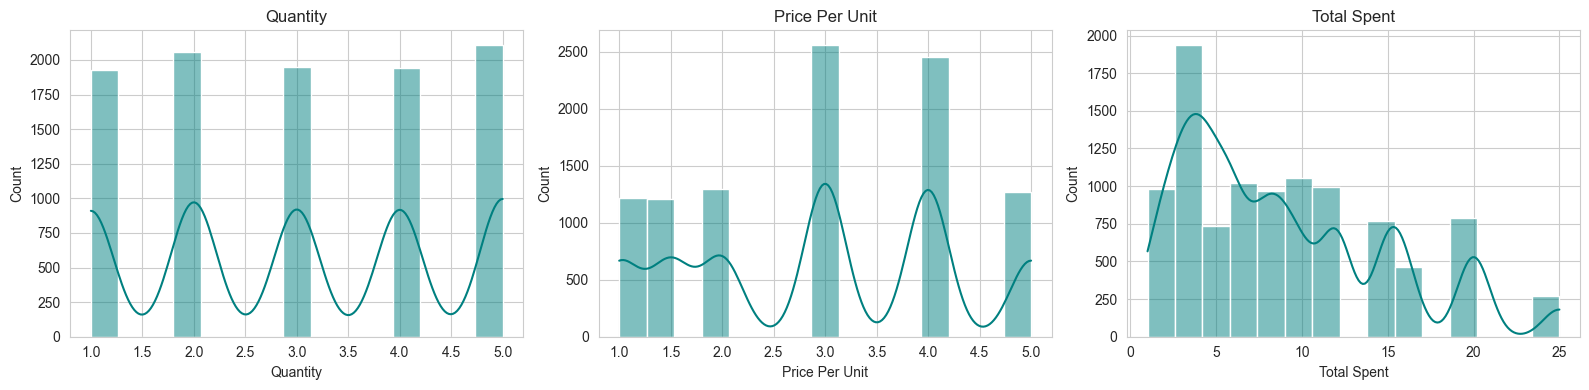

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df_clean[col].dropna(), bins=15, kde=True, ax=ax, color='teal')
    ax.set_title(f'{col}')
plt.tight_layout()
plt.show()

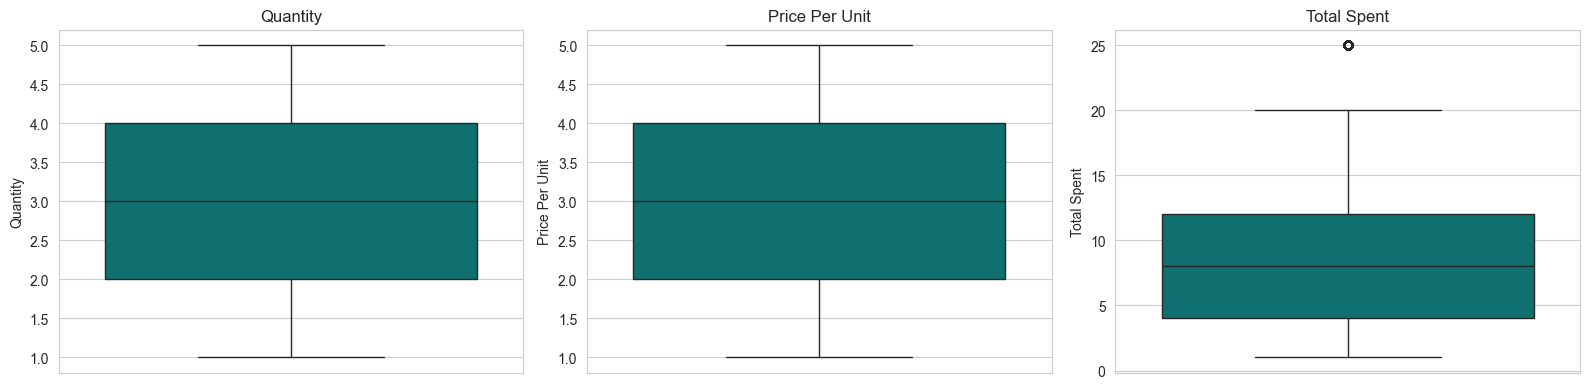

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df_clean[col].dropna(), ax=ax, color='teal')
    ax.set_title(f'{col}')
plt.tight_layout()
plt.show()

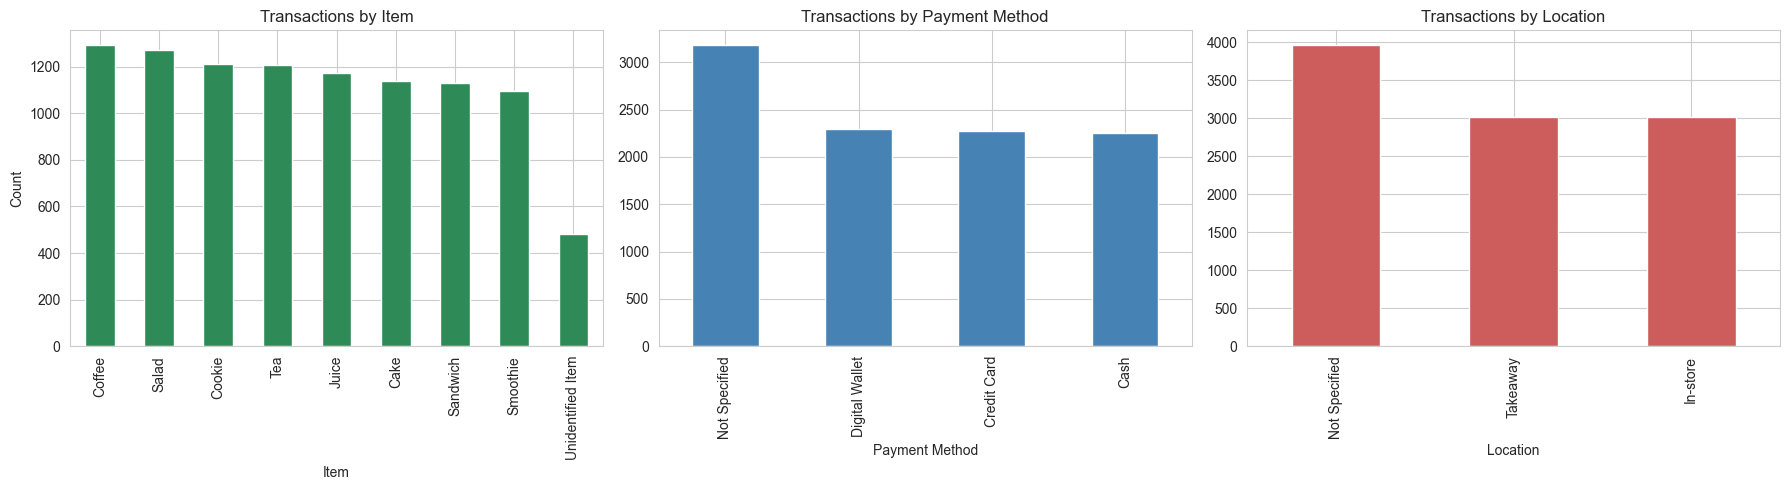

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_clean['Item'].value_counts().plot(kind='bar', ax=axes[0], color='seagreen')
axes[0].set_title('Transactions by Item')
axes[0].set_ylabel('Count')

df_clean['Payment Method'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Transactions by Payment Method')

df_clean['Location'].value_counts().plot(kind='bar', ax=axes[2], color='indianred')
axes[2].set_title('Transactions by Location')

plt.tight_layout()
plt.show()

## 5. Bivariate Analysis

Relationships between pairs of variables.

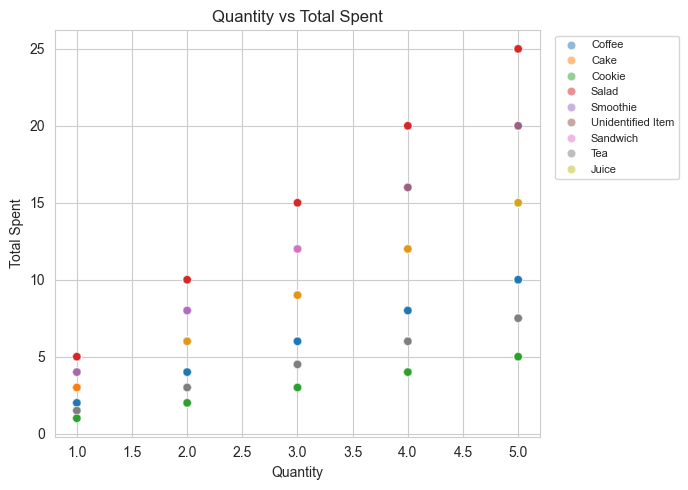

In [18]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_clean, x='Quantity', y='Total Spent', hue='Item', alpha=0.5, palette='tab10')
plt.title('Quantity vs Total Spent')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

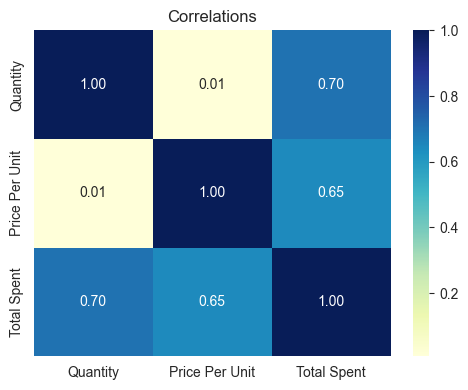

In [19]:
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlations')
plt.tight_layout()
plt.show()

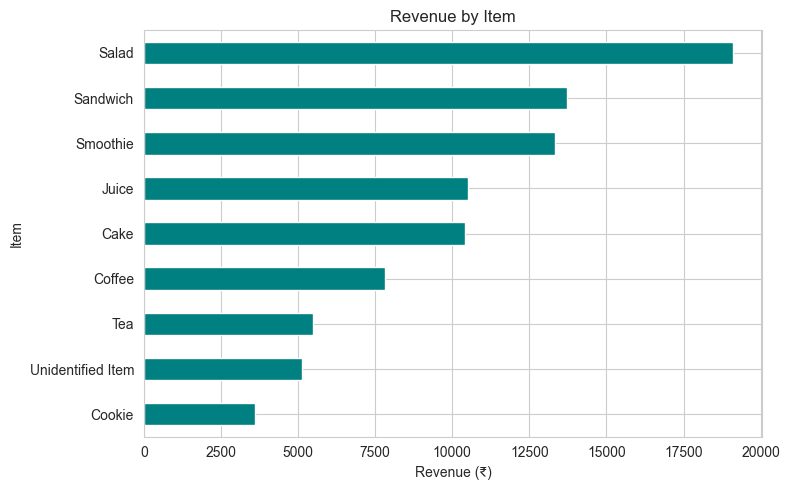

In [20]:
revenue_by_item = df_clean.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
revenue_by_item.plot(kind='barh', color='teal')
plt.title('Revenue by Item')
plt.xlabel('Revenue (₹)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

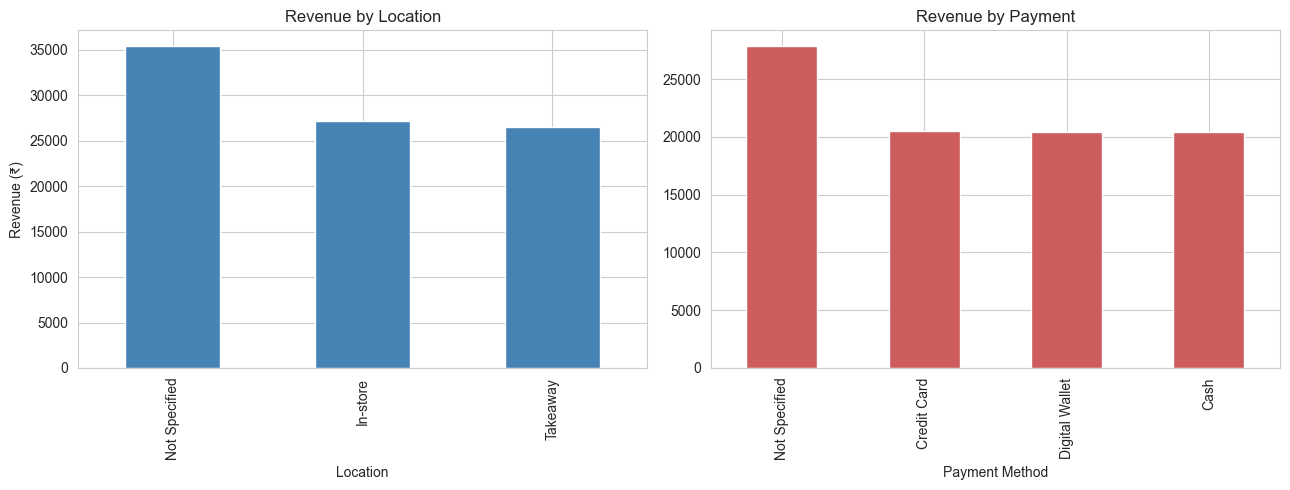

In [21]:
revenue_by_location = df_clean.groupby('Location')['Total Spent'].sum().sort_values(ascending=False)
revenue_by_payment = df_clean.groupby('Payment Method')['Total Spent'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
revenue_by_location.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Revenue by Location')
axes[0].set_ylabel('Revenue (₹)')

revenue_by_payment.plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Revenue by Payment')

plt.tight_layout()
plt.show()

## 6. Time Trends

Monthly and day-of-week patterns.

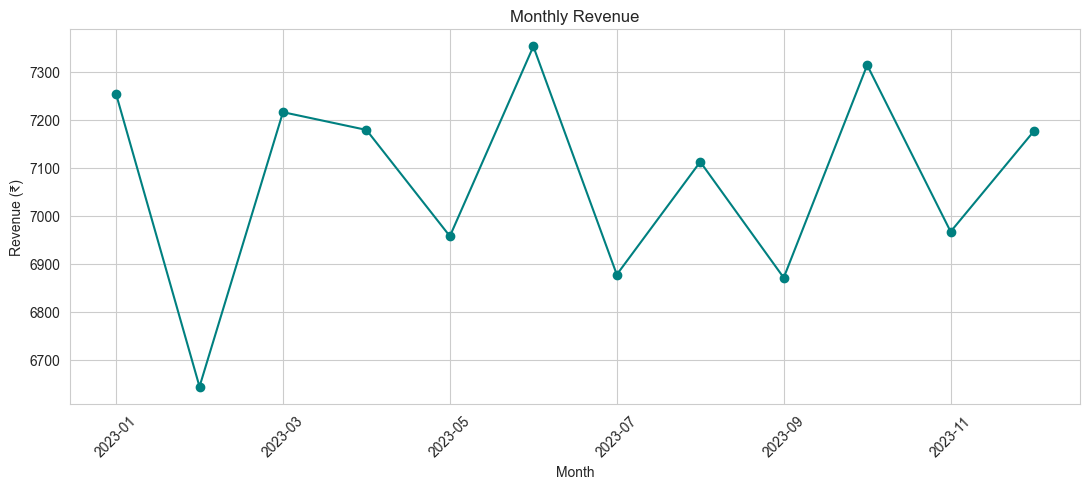

In [22]:
df_time = df_clean.dropna(subset=['Transaction Date']).copy()
df_time['Month'] = df_time['Transaction Date'].dt.to_period('M').astype(str)
df_time['DayOfWeek'] = df_time['Transaction Date'].dt.day_name()

monthly_sales = df_time.groupby('Month')['Total Spent'].sum()
plt.figure(figsize=(11, 5))
monthly_sales.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Revenue')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

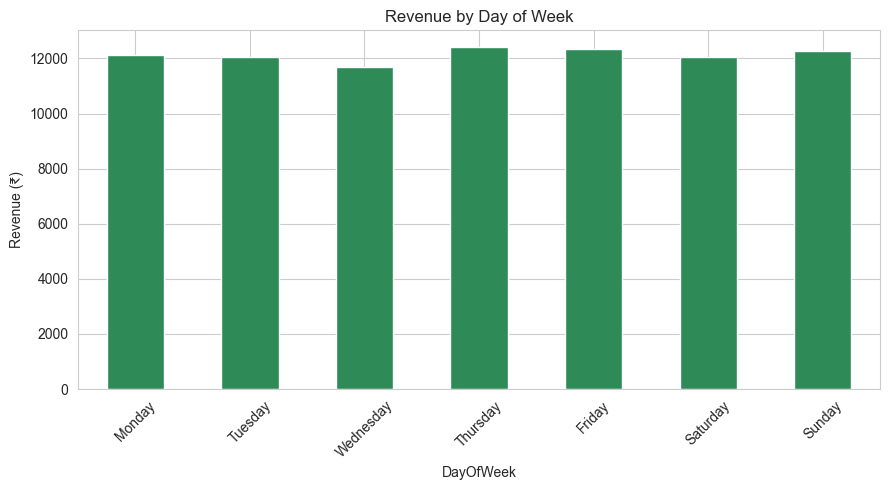

In [23]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sales_by_day = df_time.groupby('DayOfWeek')['Total Spent'].sum().reindex(day_order)

plt.figure(figsize=(9, 5))
sales_by_day.plot(kind='bar', color='seagreen')
plt.title('Revenue by Day of Week')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

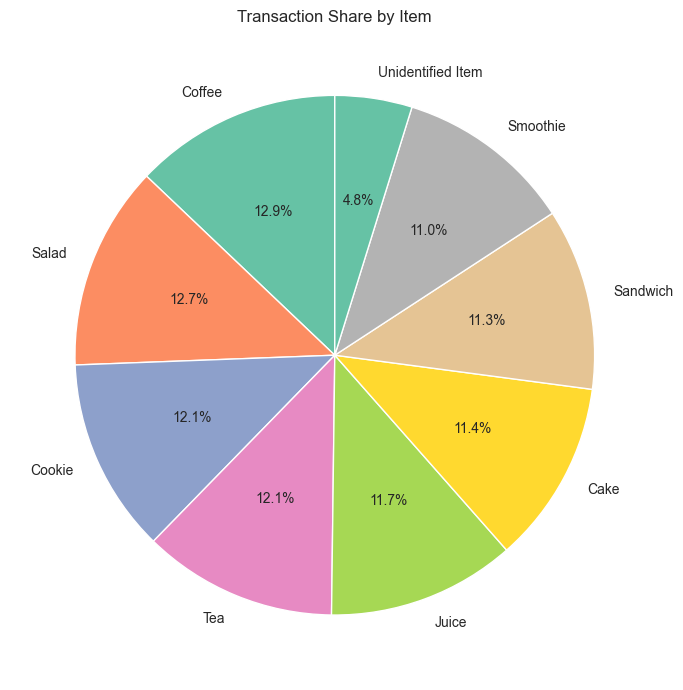

In [24]:
top_item_share = df_clean['Item'].value_counts(normalize=True).mul(100).round(1)
plt.figure(figsize=(7, 7))
plt.pie(top_item_share, labels=top_item_share.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
plt.title('Transaction Share by Item')
plt.tight_layout()
plt.show()

## 7. Takeaways

**Revenue drivers**
Sandwiches and Salads bring in the most money per item. Coffee has higher transaction volume but lower price, so it's quantity over value.

**Item composition**
Strong positive correlation between Quantity and Total Spent. This means basket size is the bigger lever — most variation comes from buying more items, not which items people pick.

**Channel split**
In-store and Takeaway split revenue fairly evenly, so neither channel dominates.

## 8. Export for Tableau

Adding Year, Month, DayOfWeek columns to make Tableau filtering easier.

In [25]:
df_export = df_clean.copy()
df_export['Year'] = df_export['Transaction Date'].dt.year
df_export['Month'] = df_export['Transaction Date'].dt.month_name()
df_export['DayOfWeek'] = df_export['Transaction Date'].dt.day_name()

df_export.to_csv('cleaned_cafe_sales.csv', index=False)
print(f"Exported {len(df_export)} rows")
df_export.head()

Exported 10000 rows


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,DayOfWeek
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023.0,September,Friday
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,2023.0,May,Tuesday
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,2023.0,July,Wednesday
3,TXN_7034554,Salad,2.0,5.0,10.0,Not Specified,Not Specified,2023-04-27,2023.0,April,Thursday
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023.0,June,Sunday
